In [1]:
using Pkg
Pkg.activate(dirname(dirname(pwd())))   # activate MyPackage
# Pkg.instantiate()
using Revise
using LMC
using LinearAlgebra
# using CairoMakie

  Activating project at `~/Documents/Work/PostdocDonosti/Packages/LMC`


In [2]:
pathof(LMC)

"/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/LMC.jl"

In [3]:

p = ParamsHF(paramsHF(1.05, 1,  1), twovalleystwospins = true); of = diagm(rand(8)) .* 0.2;

In [4]:
xxx_lmc_presets(p, of);

In [64]:
xx_drude_presets(p, of);

## Cluster

In [7]:
#input self-consistent data (band structures and fillings)
folder = 2281278
simportedvp = LMC.provide_folder_get_observables_atlas_reshuffled(folder,"vp")
simportedqah = LMC.provide_folder_get_observables_atlas_reshuffled(folder,"qah")

Self_consistent_data([[0.09177345774687988, 0.9082266953889119, 0.09177332560351777, 0.9082265632458201, 0.09177345774707828, 0.9082266953886995, 0.09177332560324447, 0.90822656324608], [0.09511348277570118, 0.9082511047894717, 0.09488496101520044, 0.9082363274508053, 0.09506482891973579, 0.9082485860070545, 0.09488496101520041, 0.9082363274508], [0.09837451965982014, 0.9082578457346432, 0.09819466351798244, 0.9082466677698788, 0.09837451965980154, 0.9082578457346596, 0.09819466212611173, 0.908246668566111], [0.10245915358429471, 0.9083252464279664, 0.10138957737766345, 0.9082700970840478, 0.1014245880034912, 0.9082721917421305, 0.10138957737766344, 0.908270097084047], [0.1063219445813836, 0.908357447941392, 0.10450540358549186, 0.9082591487666652, 0.10465143137966329, 0.9082700749993093, 0.10450540358549182, 0.908259148766665], [0.10919545986212188, 0.9083505993834553, 0.10789113601393205, 0.9082876665175774, 0.10893827608404896, 0.9083380869167671, 0.107891136013932, 0.90828766651757

In [24]:
#out put response calculations
drudePID = 4604805

drudepath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/$(drudePID)_merged_data.jld"
drudepresetpath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/$(drudePID)_merged_presets.jld"
# lmcpath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterDATA/LMC/$(lmcPID)_merged_data.jld"
# lmcpresetpath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterDATA/LMC/$(lmcPID)_merged_presets.jld"


"/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/4604805_merged_presets.jld"

In [10]:
l = LMC.readparams(folder)
pimported = ParamsHF(paramsHF(1.05, 1,  1),
    μ = 0,
    nf = l.nf[1],
    λ = l.λ[1],
    M = l.M[1],
    v = l.v[1],
    vp = l.vp[1],
    γ =l.γ[1],
    sigmaz = l.sigmaz[1],
    sigmazlayerz = l.sigmazlayerz[1],
    U1 = l.U1[1],
    U2 = l.U2[1],
    J = 0*l.J[1],
    VP =l.VP[1],
    twovalleystwospins= l.twovalleystwospins[1]);

## Calculations

In [44]:
vorbs = lmc_orb_sweep(folder, "vp", evals = 5000, T =1)

progress: 0.005 |  val: 0.004122338336303245
progress: 0.01 |  val: -0.0031381183621161236
progress: 0.015 |  val: 0.006008694324779149
progress: 0.02 |  val: 0.007190177969163428
progress: 0.025 |  val: -0.0010093950401228486
progress: 0.03 |  val: 0.002075608571707836
progress: 0.035 |  val: 0.0029128513103373775
progress: 0.04 |  val: 0.0031663216302964983
progress: 0.045 |  val: 0.00714842415520208
progress: 0.05 |  val: 0.0023012326042022827
progress: 0.055 |  val: 0.0030582857361425735
progress: 0.06 |  val: 0.008928398046884247
progress: 0.065 |  val: 0.0011833488024147393
progress: 0.07 |  val: 0.011113117706941915
progress: 0.075 |  val: -0.006926651683227013
progress: 0.08 |  val: -0.015073365831129983
progress: 0.085 |  val: -6.762919674663881e-5
progress: 0.09 |  val: 0.007407364493369221
progress: 0.095 |  val: 0.010921481365304478
progress: 0.1 |  val: 0.018710434627927576
progress: 0.105 |  val: 0.010752940850012858
progress: 0.11 |  val: 0.016519343650882607
progress: 0

([0.0, 0.020100502512562814, 0.04020100502512563, 0.06030150753768844, 0.08040201005025126, 0.10050251256281408, 0.12060301507537688, 0.1407035175879397, 0.16080402010050251, 0.18090452261306533  …  3.819095477386935, 3.8391959798994977, 3.85929648241206, 3.879396984924623, 3.899497487437186, 3.919597989949749, 3.9396984924623117, 3.959798994974874, 3.979899497487437, 4.0], Any[0.004122338336303245, -0.0031381183621161236, 0.006008694324779149, 0.007190177969163428, -0.0010093950401228486, 0.002075608571707836, 0.0029128513103373775, 0.0031663216302964983, 0.00714842415520208, 0.0023012326042022827  …  0.0035980249585902025, 0.01173454194317731, 0.011892593440771764, 0.014628577063160156, -0.0009344911912953887, -0.013299265488717541, -0.009984938977461857, -0.013094798951457985, -0.002882451968179313, 0.003940396733399844])

In [26]:
vspins = lmc_spin_sweep(folder, "vp", evals = 2)

progress: 0.005 |  val: 0.0
progress: 0.01 |  val: 0.0
progress: 0.015 |  val: 0.0
progress: 0.02 |  val: 0.0
progress: 0.025 |  val: 0.0
progress: 0.03 |  val: 0.0
progress: 0.035 |  val: 0.0
progress: 0.04 |  val: 0.0
progress: 0.045 |  val: 0.0
progress: 0.05 |  val: 0.0
progress: 0.055 |  val: 0.0
progress: 0.06 |  val: 0.0
progress: 0.065 |  val: 0.0
progress: 0.07 |  val: 0.0
progress: 0.075 |  val: 0.0
progress: 0.08 |  val: 0.0
progress: 0.085 |  val: 0.0
progress: 0.09 |  val: 0.0
progress: 0.095 |  val: 0.0
progress: 0.1 |  val: 0.0
progress: 0.105 |  val: 0.0
progress: 0.11 |  val: 0.0
progress: 0.115 |  val: 0.0
progress: 0.12 |  val: 0.0
progress: 0.125 |  val: 0.0
progress: 0.13 |  val: 0.0
progress: 0.135 |  val: 0.0
progress: 0.14 |  val: 0.0
progress: 0.145 |  val: 0.0
progress: 0.15 |  val: 0.0
progress: 0.155 |  val: 0.0
progress: 0.16 |  val: 0.0
progress: 0.165 |  val: 0.0
progress: 0.17 |  val: 0.0
progress: 0.175 |  val: 0.0
progress: 0.18 |  val: 0.0
progress: 0

([0.0, 0.020100502512562814, 0.04020100502512563, 0.06030150753768844, 0.08040201005025126, 0.10050251256281408, 0.12060301507537688, 0.1407035175879397, 0.16080402010050251, 0.18090452261306533  …  3.819095477386935, 3.8391959798994977, 3.85929648241206, 3.879396984924623, 3.899497487437186, 3.919597989949749, 3.9396984924623117, 3.959798994974874, 3.979899497487437, 4.0], Any[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

In [69]:
vdrude = drude_sweep(folder, "vp", evals = 20000, T=10)

progress: 0.005 |  val: 145.80328302161308
progress: 0.01 |  val: 217.4208116189097
progress: 0.015 |  val: 173.53477326358566
progress: 0.02 |  val: 175.18887772750892
progress: 0.025 |  val: 195.86999322831977
progress: 0.03 |  val: 180.32562412733435
progress: 0.035 |  val: 162.4630399298558
progress: 0.04 |  val: 187.44194956849398
progress: 0.045 |  val: 186.07344399765188
progress: 0.05 |  val: 160.4703125096659
progress: 0.055 |  val: 145.48212983850135
progress: 0.06 |  val: 156.38965716449482
progress: 0.065 |  val: 140.7415248520458
progress: 0.07 |  val: 145.16808181337785
progress: 0.075 |  val: 151.406265471841
progress: 0.08 |  val: 89.52535565292199
progress: 0.085 |  val: 75.68712913292521
progress: 0.09 |  val: 77.28696992508888
progress: 0.095 |  val: 84.06277745801349
progress: 0.1 |  val: 70.2201329167506
progress: 0.105 |  val: 76.39739215954023
progress: 0.11 |  val: 75.87391475314297
progress: 0.115 |  val: 78.86483056831374
progress: 0.12 |  val: 77.663892443980

([0.0, 0.020100502512562814, 0.04020100502512563, 0.06030150753768844, 0.08040201005025126, 0.10050251256281408, 0.12060301507537688, 0.1407035175879397, 0.16080402010050251, 0.18090452261306533  …  3.819095477386935, 3.8391959798994977, 3.85929648241206, 3.879396984924623, 3.899497487437186, 3.919597989949749, 3.9396984924623117, 3.959798994974874, 3.979899497487437, 4.0], Any[145.80328302161308, 217.4208116189097, 173.53477326358566, 175.18887772750892, 195.86999322831977, 180.32562412733435, 162.4630399298558, 187.44194956849398, 186.07344399765188, 160.4703125096659  …  4.281157719694664, 5.196103138712259, 3.4184251006230912, 2.6675372120765846, 2.180976399923536, 1.7732354192258875, 1.370616498981697, 1.479948705407227, 1.2814811499012808, 1.6325092239141226])

## Plots

In [21]:
using CairoMakie, LaTeXStrings, JLD2

In [31]:
ppd = load(drudepresetpath)
pddata = load(drudepath)
vals = ppd["presets"]
evals = vals["comp_struct"].evals
_, first_value = first(pddata["merged"])
keylist = keys(first_value)

KeySet for a Dict{String, Any} with 3 entries. Keys:
  "n"
  "p"
  "mu"

In [36]:
Ezs = []
obsmat = []
for (path, d) in pddata["merged"]
        d
end

In [15]:
ppd = load(drudepresetpath)
pddata = load(drudepath)


vals = ppd["presets"]
interpPID = vals["comp_struct"].interpPID
pdPID = vals["comp_struct"].phasediagPID
PID = vals["comp_struct"].PID
evals = vals["comp_struct"].evals
_, first_value = first(pddata["merged"])
keylist = keys(first_value)
Ezs = []
obsmat = []
for (path, d) in pddata["merged"]
        Ez = d["Ezs"][1]
        o = d["obs_list"]
        push!(Ezs, Ez)
        push!(obsmat, o)
end
    sorted_inds = sortperm(Ezs)
    νlist = first_value["nu_list"]

ArgumentError: ArgumentError: No file exists at given path: /Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterDATA/LMC/4604805_merged_presets.jld

In [16]:

# fig = Figure()
# ax = Axis(fig[1,1], xlabel = L"$\nu$", ylabel = L"$E\text{ }[eV]$")
ylims!(ax, -0.05,0.05)
scatter!(ax, [v for v in vorbs[1]], [v for v in vorbs[2]])
fig


UndefVarError: UndefVarError: `ax` not defined

In [17]:

# fig = Figure()
# ax = Axis(fig[1,1], xlabel = L"$\nu$", ylabel = L"$E\text{ }[eV]$")
ylims!(ax, -0,400)
lines!(ax, [v for v in vorbs[1]], [v for v in vdrude[2]])
fig


UndefVarError: UndefVarError: `ax` not defined

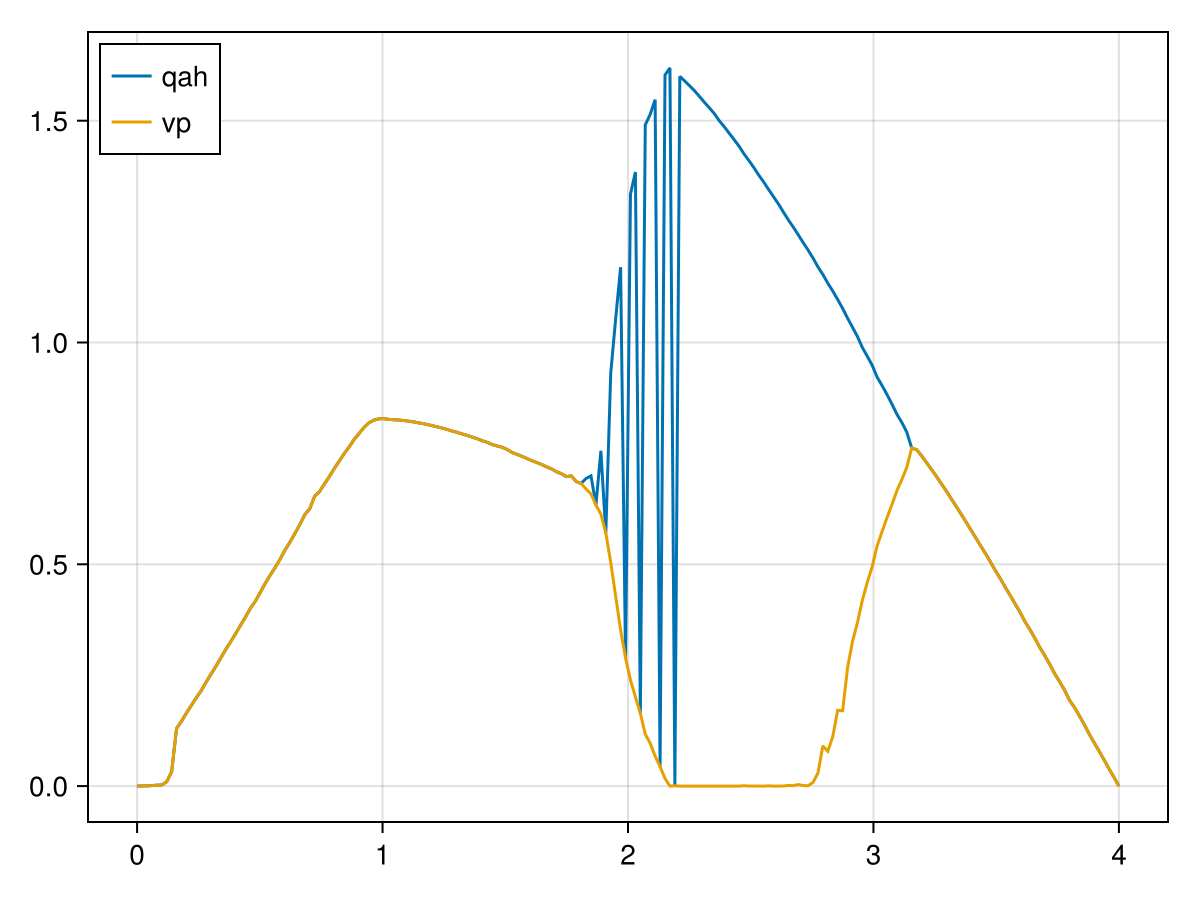

In [18]:
function tauz(s::Self_consistent_data)
    taus = zeros(Float64,length(s.ofmats))
    for i in 1:length(s.ofmats)
        taus[i] = abs(sum(s.ofmats[i] .* [1, 1, -1, -1, 1, 1, -1, -1]))
    end
    taus
end

t1 = tauz(simportedvp)
t2 = tauz(simportedqah)
fig = Figure()
ax = Axis(fig[1,1]) 
lines!(ax, simportedvp.ns, t1, label = "qah")
lines!(ax, simportedvp.ns, t2, label = "vp")
axislegend(ax, position = :lt)
fig